# 삼성전자 하루 방향 예측: ML · Transformer · 금융 시계열 파운데이션 모델 비교

이 노트북은 **Google Colab에서 위에서부터 순서대로 실행**하도록 만들었습니다. 삼성전자(005930)의 당일 종가가 전일 종가보다 얼마나 움직였는지를 다음 세 클래스로 예측합니다.

- **하락(0)**: 수익률 < -0.5%
- **보합(1)**: -0.5% ≤ 수익률 ≤ +0.5%
- **상승(2)**: 수익률 > +0.5%

동일한 시간 순서 검증에서 다음 방법을 비교합니다.

1. 항상 보합을 예측하는 기준선
2. 다항 로지스틱 회귀
3. LightGBM
4. 직접 학습하는 작은 Transformer Encoder
5. 금융 OHLCV 전용 시계열 파운데이션 모델 **Kronos-small**(zero-shot)

> 중요: 주가 방향은 잡음이 매우 큰 문제입니다. 이 노트북은 투자수익을 보장하지 않으며, **어떤 모델이 동일 조건의 과거 외삽 검증에서 상대적으로 나았는지** 확인하기 위한 연구용 도구입니다.

### 누수 방지 원칙

- 삼성전자·KOSPI 지표는 예측일의 전 거래일까지만 사용합니다.
- 미국시장 자료는 미국 세션 날짜에 하루를 더해 한국 아침에 도착한 것으로 정렬합니다.
- 데이터는 무작위로 섞지 않고 과거로 학습한 뒤 미래 구간을 예측합니다.
- 가격 MAE가 아니라 방향 정확도, 균형정확도, Macro-F1, Log loss, Brier score를 평가합니다.


## 0. Colab 런타임

`런타임 → 런타임 유형 변경 → T4 GPU`를 권장합니다. `QUICK_MODE=True`이면 Transformer와 Kronos 평가 구간을 줄여 빠르게 확인합니다. 전체 검증은 설정 셀에서 `QUICK_MODE=False`로 바꾸세요.


In [1]:
%%capture
!pip -q install -U yfinance lightgbm seaborn joblib
!pip -q install einops==0.8.1 huggingface_hub==0.33.1 tqdm==4.67.1 safetensors==0.6.2
![ -d /content/Kronos ] || git clone --depth 1 https://github.com/shiyu-coder/Kronos.git /content/Kronos

In [2]:
import os
import sys
import gc
import json
import math
import random
import time
import warnings
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from tqdm.auto import tqdm

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    confusion_matrix,
)
from lightgbm import LGBMClassifier, LGBMRegressor
import joblib

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if DEVICE.type != "cuda":
    print("⚠️ CPU에서도 실행되지만 Transformer/Kronos가 느립니다. Colab GPU를 권장합니다.")

Python: 3.13.15
PyTorch: 2.11.0+cu128
Device: cuda


## 1. 실험 설정

처음에는 아래 기본값으로 실행하는 것을 권장합니다. `KRONOS_EVAL_DAYS`는 파운데이션 모델의 과거 예측 횟수이며, 크게 잡을수록 훨씬 오래 걸립니다.


In [3]:
START_DATE = "2015-01-01"
END_DATE = None                 # None이면 현재까지
NEUTRAL_BAND = 0.005            # ±0.5%

FIRST_TEST_DATE = "2021-01-01"
TEST_MONTHS = 6                 # 워크포워드 한 구간의 길이
ROLLING_TRAIN_YEARS = 5         # 각 구간에서 최근 5년만 학습

QUICK_MODE = True
MAX_FOLDS = 3 if QUICK_MODE else None

SEQ_LEN = 30
TRANSFORMER_EPOCHS = 8 if QUICK_MODE else 25
TRANSFORMER_PATIENCE = 3 if QUICK_MODE else 5
BATCH_SIZE = 64

RUN_KRONOS = True
KRONOS_LOOKBACK = 400
KRONOS_EVAL_DAYS = 20 if QUICK_MODE else 60
KRONOS_MC_SAMPLES = 3 if QUICK_MODE else 8

# 한국 휴일 때문에 자동 계산 날짜가 틀리면 "2026-09-02"처럼 직접 지정하세요.
PREDICTION_DATE_OVERRIDE = None

LABEL_NAMES = {0: "하락", 1: "보합", 2: "상승"}
PROB_COLS = ["p_down", "p_flat", "p_up"]

print({
    "QUICK_MODE": QUICK_MODE,
    "Transformer epochs": TRANSFORMER_EPOCHS,
    "Kronos evaluation days": KRONOS_EVAL_DAYS,
    "Kronos Monte Carlo samples": KRONOS_MC_SAMPLES,
})

{'QUICK_MODE': True, 'Transformer epochs': 8, 'Kronos evaluation days': 20, 'Kronos Monte Carlo samples': 3}


## 2. 데이터 다운로드

Colab에서 별도 API 키 없이 재현할 수 있도록 Yahoo Finance를 사용합니다. 일부 티커가 일시적으로 실패해도 나머지 데이터로 계속 진행합니다.

**예측일 오전 7시까지 사용할 신호**

- 삼성전자·KOSPI·KOSPI200의 과거 수익률, 추세, 변동성, 거래량
- SOX, Nasdaq, S&P 500, Micron, Nvidia, TSMC ADR, EWY
- 원/달러, 달러지수, VIX, 미국 10년물 금리, WTI

Yahoo Finance는 연구·교육용 편의 데이터입니다. 실제 운영에서는 KRX, 한국은행 ECOS, CME 등 원천 자료로 교체하는 것이 좋습니다.


In [4]:
ASSETS = {
    "samsung": "005930.KS",
    "kospi": "^KS11",
    "kospi200": "^KS200",
    "sox": "^SOX",
    "nasdaq": "^IXIC",
    "sp500": "^GSPC",
    "micron": "MU",
    "nvidia": "NVDA",
    "tsmc_adr": "TSM",
    "korea_etf": "EWY",
    "usdkrw": "KRW=X",
    "dxy": "DX-Y.NYB",
    "vix": "^VIX",
    "us10y": "^TNX",
    "wti": "CL=F",
}


def _flatten_yf_columns(frame):
    frame = frame.copy()
    if isinstance(frame.columns, pd.MultiIndex):
        frame.columns = frame.columns.get_level_values(0)
    frame.columns = [str(c).strip().lower().replace(" ", "_") for c in frame.columns]
    return frame


def download_one(ticker, start=START_DATE, end=END_DATE, retries=3):
    last_error = None
    for attempt in range(retries):
        try:
            frame = yf.download(
                ticker,
                start=start,
                end=end,
                auto_adjust=False,
                progress=False,
                threads=False,
                timeout=30,
            )
            frame = _flatten_yf_columns(frame)
            if frame.empty:
                raise ValueError("empty response")
            frame.index = pd.to_datetime(frame.index)
            if frame.index.tz is not None:
                frame.index = frame.index.tz_localize(None)
            frame.index = frame.index.normalize()
            frame = frame[~frame.index.duplicated(keep="last")].sort_index()
            if "adj_close" not in frame.columns and "close" in frame.columns:
                frame["adj_close"] = frame["close"]
            keep = [c for c in ["open", "high", "low", "close", "adj_close", "volume"] if c in frame]
            return frame[keep].astype(float)
        except Exception as exc:
            last_error = exc
            time.sleep(1.5 * (attempt + 1))
    print(f"⚠️ {ticker} 다운로드 실패: {last_error}")
    return pd.DataFrame()


raw = {}
for name, ticker in tqdm(ASSETS.items(), desc="Downloading"):
    raw[name] = download_one(ticker)

if raw["samsung"].empty:
    raise RuntimeError("삼성전자 데이터 다운로드에 실패했습니다. 잠시 후 셀을 다시 실행하세요.")

quality = []
for name, frame in raw.items():
    quality.append({
        "asset": name,
        "ticker": ASSETS[name],
        "rows": len(frame),
        "first": frame.index.min() if len(frame) else pd.NaT,
        "last": frame.index.max() if len(frame) else pd.NaT,
    })
pd.DataFrame(quality)

Downloading:   0%|          | 0/15 [00:00<?, ?it/s]

,asset,ticker,rows,first,last
0,samsung,005930.KS,2860,2015-01-02,2026-09-02
1,kospi,^KS11,2859,2015-01-02,2026-09-02
2,kospi200,^KS200,2824,2015-01-02,2026-09-02
3,sox,^SOX,2932,2015-01-02,2026-09-01
4,nasdaq,^IXIC,2932,2015-01-02,2026-09-01
5,sp500,^GSPC,2932,2015-01-02,2026-09-01
6,micron,MU,2933,2015-01-02,2026-09-01
7,nvidia,NVDA,2933,2015-01-02,2026-09-01
8,tsmc_adr,TSM,2933,2015-01-02,2026-09-01
9,korea_etf,EWY,2932,2015-01-02,2026-09-01


## 3. 특징 생성과 시각 정렬

행의 날짜가 예측 대상 거래일입니다. 삼성전자와 한국시장 신호에는 `shift(1)`을 적용해 전 거래일까지만 사용합니다. 미국시장 날짜 `d`의 종가는 한국시간으로 다음 날 새벽에 확정되므로 가용 날짜를 `d+1일`로 옮긴 뒤 가장 최근 자료를 결합합니다. 주말은 이전 값을 이어받되 미래 값으로 뒤를 채우지 않습니다.


In [5]:
def rsi(close, window=14):
    delta = close.diff()
    gain = delta.clip(lower=0).rolling(window).mean()
    loss = (-delta.clip(upper=0)).rolling(window).mean()
    rs = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def rolling_zscore(series, window=20):
    mean = series.rolling(window).mean()
    std = series.rolling(window).std()
    return (series - mean) / std.replace(0, np.nan)


def merge_latest_available(base_index, series, availability_days=1):
    values = series.dropna().copy()
    values.index = (pd.to_datetime(values.index).tz_localize(None).normalize()
                    + pd.Timedelta(days=availability_days))
    values = values.groupby(level=0).last().sort_index()
    left = pd.DataFrame({"date": pd.DatetimeIndex(base_index)}).sort_values("date")
    right = values.rename("value").reset_index()
    right.columns = ["available_date", "value"]
    merged = pd.merge_asof(
        left,
        right.sort_values("available_date"),
        left_on="date",
        right_on="available_date",
        direction="backward",
        tolerance=pd.Timedelta(days=7),
    )
    return pd.Series(merged["value"].to_numpy(), index=left["date"], name=series.name)


sam = raw["samsung"].copy()
sam = sam.dropna(subset=["open", "high", "low", "close", "adj_close"])

# 장중에 실행했을 때 Yahoo의 미완성 당일 일봉이 들어오면 제거한다.
now_kst = pd.Timestamp.now(tz="Asia/Seoul")
if (
    len(sam)
    and sam.index.max().date() == now_kst.date()
    and (now_kst.hour, now_kst.minute) < (15, 40)
):
    print("미완성 당일 일봉 제외:", sam.index.max().date())
    sam = sam.iloc[:-1].copy()

last_samsung_date = sam.index.max()

if PREDICTION_DATE_OVERRIDE:
    prediction_date = pd.Timestamp(PREDICTION_DATE_OVERRIDE).normalize()
else:
    prediction_date = pd.bdate_range(last_samsung_date + pd.Timedelta(days=1), periods=1)[0]

all_dates = sam.index.union(pd.DatetimeIndex([prediction_date])).sort_values()
feat = pd.DataFrame(index=all_dates)

sam_close = sam["adj_close"]
sam_ret = sam_close.pct_change()
sam_gap = sam["open"] / sam["close"].shift(1) - 1
sam_range = (sam["high"] - sam["low"]) / sam["close"]
sam_log_volume = np.log1p(sam["volume"].clip(lower=0))

# 예측일에는 전 거래일까지 확정된 값만 들어간다.
feat["sam_ret_1"] = sam_ret.reindex(all_dates).shift(1)
feat["sam_ret_2"] = sam_close.pct_change(2).reindex(all_dates).shift(1)
feat["sam_ret_5"] = sam_close.pct_change(5).reindex(all_dates).shift(1)
feat["sam_ret_20"] = sam_close.pct_change(20).reindex(all_dates).shift(1)
feat["sam_vol_5"] = sam_ret.rolling(5).std().reindex(all_dates).shift(1)
feat["sam_vol_20"] = sam_ret.rolling(20).std().reindex(all_dates).shift(1)
feat["sam_gap_1"] = sam_gap.reindex(all_dates).shift(1)
feat["sam_range_1"] = sam_range.reindex(all_dates).shift(1)
feat["sam_volume_z20"] = rolling_zscore(sam_log_volume, 20).reindex(all_dates).shift(1)
feat["sam_price_to_ma20"] = (sam_close / sam_close.rolling(20).mean() - 1).reindex(all_dates).shift(1)
feat["sam_price_to_ma60"] = (sam_close / sam_close.rolling(60).mean() - 1).reindex(all_dates).shift(1)
feat["sam_rsi14"] = (rsi(sam_close, 14) / 100).reindex(all_dates).shift(1)

# 한국시장: 같은 날짜의 종가는 오전 7시에 아직 없으므로 1거래일 지연.
for name in ["kospi", "kospi200"]:
    frame = raw.get(name, pd.DataFrame())
    if not frame.empty and "adj_close" in frame:
        close = frame["adj_close"]
        feat[f"{name}_ret_1"] = close.pct_change().reindex(all_dates).shift(1)
        feat[f"{name}_ret_5"] = close.pct_change(5).reindex(all_dates).shift(1)
        feat[f"{name}_vol_20"] = close.pct_change().rolling(20).std().reindex(all_dates).shift(1)

# 해외시장: 미국 세션 d의 정보는 한국 날짜 d+1 아침에 사용 가능하다고 보수적으로 정렬.
GLOBAL_ASSETS = [
    "sox", "nasdaq", "sp500", "micron", "nvidia", "tsmc_adr",
    "korea_etf", "usdkrw", "dxy", "vix", "us10y", "wti",
]
for name in GLOBAL_ASSETS:
    frame = raw.get(name, pd.DataFrame())
    if frame.empty or "adj_close" not in frame:
        continue
    close = frame["adj_close"]
    feat[f"{name}_ret_1"] = merge_latest_available(all_dates, close.pct_change(), 1)
    feat[f"{name}_ret_5"] = merge_latest_available(all_dates, close.pct_change(5), 1)
    if name in ["vix", "us10y", "usdkrw", "dxy", "wti"]:
        feat[f"{name}_level_z60"] = merge_latest_available(
            all_dates, rolling_zscore(close, 60), 1
        )

# 발표 빈도가 다른 자료를 합칠 때 미래값으로 backfill하지 않는다.
feat = feat.replace([np.inf, -np.inf], np.nan).ffill(limit=5)

target_return = sam_close.pct_change().reindex(all_dates)
target = np.select(
    [target_return < -NEUTRAL_BAND, target_return > NEUTRAL_BAND],
    [0, 2],
    default=1,
).astype(float)
target[pd.isna(target_return)] = np.nan

feat["target_return"] = target_return
feat["target"] = target

# 결측이 지나치게 많은 특징은 제거한다.
candidate_features = [c for c in feat.columns if c not in ["target", "target_return"]]
coverage = feat.loc[sam.index, candidate_features].notna().mean()
feature_cols = coverage[coverage >= 0.80].index.tolist()
removed_features = coverage[coverage < 0.80].index.tolist()

model_df = feat.loc[sam.index, feature_cols + ["target_return", "target"]].dropna().copy()
model_df["target"] = model_df["target"].astype(int)

live_row = feat.loc[[prediction_date], feature_cols].copy()
for col in feature_cols:
    if pd.isna(live_row.iloc[0][col]):
        live_row.loc[prediction_date, col] = model_df[col].iloc[-1]

print("Model rows:", len(model_df))
print("Features:", len(feature_cols))
print("Removed low-coverage features:", removed_features)
print("Backtest range:", model_df.index.min().date(), "~", model_df.index.max().date())
print("Candidate prediction date:", prediction_date.date())

assert prediction_date > last_samsung_date
assert model_df.index.is_monotonic_increasing
assert model_df[feature_cols].notna().all().all()


Model rows: 2774
Features: 47
Removed low-coverage features: []
Backtest range: 2015-04-01 ~ 2026-07-27
Candidate prediction date: 2026-09-03


,class,count,ratio
target,,,
0,하락,958,34.5%
1,보합,776,28.0%
2,상승,1040,37.5%


/tmp/ipykernel_2882/4028649729.py:17: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2882/4028649729.py:17: UserWarning: Glyph 46973 (\N{HANGUL SYLLABLE RAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2882/4028649729.py:17: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2882/4028649729.py:17: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2882/4028649729.py:17: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2882/4028649729.py:17: UserWarning: Glyph 49849 (\N{HANGUL SYLLABLE SEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from 

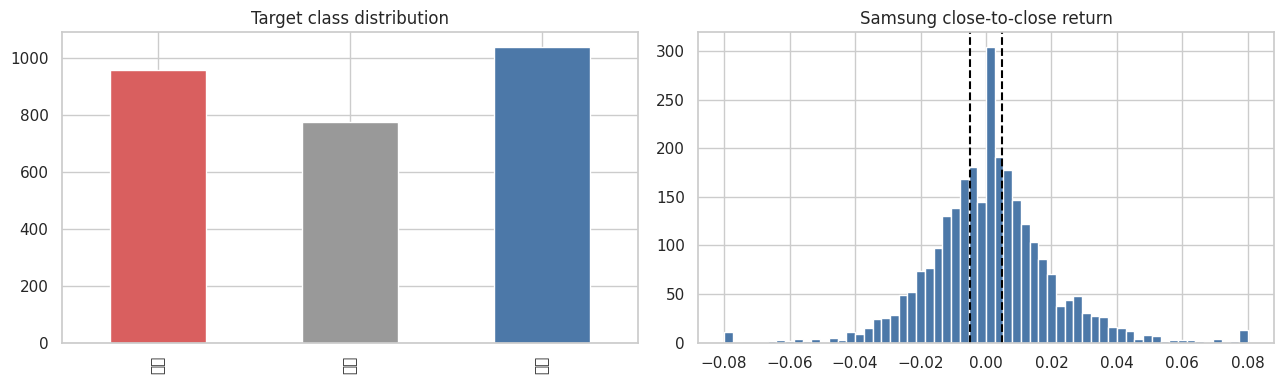

In [6]:
class_counts = model_df["target"].value_counts().sort_index()
class_table = pd.DataFrame({
    "class": [LABEL_NAMES[i] for i in class_counts.index],
    "count": class_counts.values,
    "ratio": class_counts.values / class_counts.sum(),
}, index=class_counts.index)
display(class_table.style.format({"ratio": "{:.1%}"}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
class_table.set_index("class")["count"].plot.bar(ax=axes[0], color=["#d95f5f", "#999999", "#4c78a8"])
axes[0].set_title("Target class distribution")
axes[0].set_xlabel("")
model_df["target_return"].clip(-0.08, 0.08).hist(bins=60, ax=axes[1], color="#4c78a8")
axes[1].axvline(-NEUTRAL_BAND, color="black", ls="--")
axes[1].axvline(NEUTRAL_BAND, color="black", ls="--")
axes[1].set_title("Samsung close-to-close return")
plt.tight_layout()
plt.show()


## 4. 워크포워드 검증과 공통 평가함수

각 폴드는 과거 5년을 학습하고 다음 6개월을 예측합니다. `QUICK_MODE=True`에서는 가장 최근 3개 폴드만 실행합니다. 모든 모델의 확률 열 순서는 `[하락, 보합, 상승]`으로 고정합니다.


In [7]:
X = model_df[feature_cols].to_numpy(dtype=np.float32)
y = model_df["target"].to_numpy(dtype=np.int64)
dates = model_df.index


def make_walk_forward_folds(dates_index):
    folds = []
    start = pd.Timestamp(FIRST_TEST_DATE)
    max_date = dates_index.max()
    fold_no = 0
    while start <= max_date:
        end = start + pd.DateOffset(months=TEST_MONTHS)
        train_start = start - pd.DateOffset(years=ROLLING_TRAIN_YEARS)
        train_idx = np.where((dates_index >= train_start) & (dates_index < start))[0]
        test_idx = np.where((dates_index >= start) & (dates_index < end))[0]
        if len(train_idx) >= 500 and len(test_idx) >= 20:
            folds.append({
                "fold": fold_no,
                "train_idx": train_idx,
                "test_idx": test_idx,
                "train_start": dates_index[train_idx[0]],
                "train_end": dates_index[train_idx[-1]],
                "test_start": dates_index[test_idx[0]],
                "test_end": dates_index[test_idx[-1]],
            })
            fold_no += 1
        start = end
    if MAX_FOLDS is not None:
        folds = folds[-MAX_FOLDS:]
    return folds


folds = make_walk_forward_folds(dates)
if not folds:
    raise RuntimeError("워크포워드 폴드가 없습니다. START_DATE 또는 FIRST_TEST_DATE를 확인하세요.")

display(pd.DataFrame([{k: v for k, v in f.items() if not k.endswith("idx")} for f in folds]))


def multiclass_brier(y_true, probs):
    onehot = np.eye(3)[np.asarray(y_true, dtype=int)]
    return np.mean(np.sum((np.asarray(probs) - onehot) ** 2, axis=1))


def prediction_frame(model_name, row_dates, y_true, probs, fold_id=None, extra=None):
    probs = np.asarray(probs, dtype=float)
    probs = np.clip(probs, 1e-7, 1 - 1e-7)
    probs = probs / probs.sum(axis=1, keepdims=True)
    out = pd.DataFrame({
        "date": pd.to_datetime(row_dates),
        "y_true": np.asarray(y_true, dtype=int),
        "y_pred": probs.argmax(axis=1),
        "p_down": probs[:, 0],
        "p_flat": probs[:, 1],
        "p_up": probs[:, 2],
        "model": model_name,
        "fold": fold_id,
    })
    if extra:
        for key, value in extra.items():
            out[key] = value
    return out


def metric_row(frame):
    true = frame["y_true"].to_numpy(dtype=int)
    pred = frame["y_pred"].to_numpy(dtype=int)
    probs = frame[PROB_COLS].to_numpy(dtype=float)
    return {
        "n": len(frame),
        "accuracy": accuracy_score(true, pred),
        "balanced_accuracy": balanced_accuracy_score(true, pred),
        "macro_f1": f1_score(true, pred, average="macro", zero_division=0),
        "log_loss": log_loss(true, probs, labels=[0, 1, 2]),
        "brier": multiclass_brier(true, probs),
    }


def summarize_predictions(predictions):
    rows = []
    for name, group in predictions.groupby("model"):
        rows.append({"model": name, **metric_row(group)})
    return pd.DataFrame(rows).set_index("model").sort_values("balanced_accuracy", ascending=False)


,fold,train_start,train_end,test_start,test_end
0,8,2020-01-02,2024-12-30,2025-01-02,2025-06-30
1,9,2020-07-01,2025-06-30,2025-07-01,2025-12-30
2,10,2021-01-04,2025-12-30,2026-01-02,2026-06-30


## 5. 기준선 · 로지스틱 회귀 · LightGBM

복잡한 모델은 반드시 단순 기준선보다 미래 구간에서 좋아야 합니다. 클래스 불균형을 고려해 로지스틱과 LightGBM 모두 균형 가중치를 사용합니다.


In [8]:
tabular_predictions = []
lgb_importances = []

for fold in tqdm(folds, desc="Tabular walk-forward"):
    tr, te = fold["train_idx"], fold["test_idx"]

    # 항상 보합 기준선. 확률은 학습구간의 클래스 빈도를 사용하되 예측 클래스만 보합으로 고정.
    prior = np.bincount(y[tr], minlength=3).astype(float) + 1
    prior = prior / prior.sum()
    base_probs = np.tile(prior, (len(te), 1))
    # argmax가 보합이 아니어도 명시적으로 보합 예측이 되도록 확률을 조정한다.
    base_probs[:, 1] = np.maximum(base_probs[:, 1], base_probs.max(axis=1) + 1e-3)
    base_probs = base_probs / base_probs.sum(axis=1, keepdims=True)
    tabular_predictions.append(prediction_frame(
        "Always flat", dates[te], y[te], base_probs, fold["fold"]
    ))

    logistic = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=0.25,
            max_iter=3000,
            class_weight="balanced",
            random_state=SEED,
        )),
    ])
    logistic.fit(X[tr], y[tr])
    p_log = logistic.predict_proba(X[te])
    # sklearn의 classes_ 순서를 [0,1,2]로 재정렬
    classes = logistic.named_steps["model"].classes_
    p_log = p_log[:, np.argsort(classes)]
    tabular_predictions.append(prediction_frame(
        "Logistic", dates[te], y[te], p_log, fold["fold"]
    ))

    lgbm = LGBMClassifier(
        objective="multiclass",
        num_class=3,
        n_estimators=300,
        learning_rate=0.03,
        num_leaves=15,
        min_child_samples=30,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.5,
        reg_lambda=2.0,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1,
    )
    lgbm.fit(X[tr], y[tr])
    p_lgb = lgbm.predict_proba(X[te])
    p_lgb = p_lgb[:, np.argsort(lgbm.classes_)]
    tabular_predictions.append(prediction_frame(
        "LightGBM", dates[te], y[te], p_lgb, fold["fold"]
    ))
    lgb_importances.append(lgbm.feature_importances_)

tabular_predictions = pd.concat(tabular_predictions, ignore_index=True)
display(summarize_predictions(tabular_predictions).style.format("{:.4f}"))


Tabular walk-forward:   0%|          | 0/3 [00:00<?, ?it/s]

,n,accuracy,balanced_accuracy,macro_f1,log_loss,brier
model,,,,,,
LightGBM,361.0000,0.5152,0.4673,0.4730,1.0260,0.6104
Logistic,361.0000,0.5208,0.4426,0.4398,1.0154,0.6067
Always flat,361.0000,0.1911,0.3333,0.1070,1.1099,0.6741


## 6. 직접 학습하는 Transformer Encoder

30거래일의 특징 시퀀스를 입력받아 마지막 토큰에서 세 방향의 확률을 출력합니다. 각 폴드마다 scaler와 모델을 과거 데이터로만 다시 학습합니다. 작은 데이터에서 대형 Transformer는 과적합하기 쉬우므로 의도적으로 작은 구조를 사용합니다.


In [9]:
class DirectionTransformer(nn.Module):
    def __init__(self, n_features, seq_len, d_model=64, nhead=4, num_layers=2, dropout=0.20):
        super().__init__()
        self.seq_len = seq_len
        self.input_proj = nn.Linear(n_features, d_model)
        self.position = nn.Parameter(torch.zeros(1, seq_len, d_model))
        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 3),
        )

    def forward(self, x):
        z = self.input_proj(x) + self.position[:, :x.size(1)]
        z = self.encoder(z)
        return self.head(self.norm(z[:, -1]))


def sequences_for_indices(X_scaled, y_array, target_indices, seq_len):
    seq_x, seq_y, kept = [], [], []
    for idx in target_indices:
        if idx < seq_len - 1:
            continue
        seq_x.append(X_scaled[idx - seq_len + 1: idx + 1])
        seq_y.append(y_array[idx])
        kept.append(idx)
    if not seq_x:
        return np.empty((0, seq_len, X_scaled.shape[1])), np.array([]), np.array([])
    return np.asarray(seq_x, dtype=np.float32), np.asarray(seq_y, dtype=np.int64), np.asarray(kept)


def train_transformer(X_array, y_array, train_indices, epochs=TRANSFORMER_EPOCHS):
    scaler = StandardScaler().fit(X_array[train_indices])
    X_scaled = scaler.transform(X_array).astype(np.float32)

    valid_targets = train_indices[train_indices >= SEQ_LEN - 1]
    cut = max(1, int(len(valid_targets) * 0.85))
    fit_targets = valid_targets[:cut]
    val_targets = valid_targets[cut:]
    if len(val_targets) < 10:
        val_targets = valid_targets[-max(10, len(valid_targets) // 10):]
        fit_targets = valid_targets[:len(valid_targets) - len(val_targets)]

    X_fit, y_fit, _ = sequences_for_indices(X_scaled, y_array, fit_targets, SEQ_LEN)
    X_val, y_val, _ = sequences_for_indices(X_scaled, y_array, val_targets, SEQ_LEN)

    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_fit), torch.from_numpy(y_fit)),
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=False,
    )
    val_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val)),
        batch_size=BATCH_SIZE * 2,
        shuffle=False,
    )

    model = DirectionTransformer(X_array.shape[1], SEQ_LEN).to(DEVICE)
    counts = np.bincount(y_fit, minlength=3).astype(float)
    weights = len(y_fit) / (3 * np.maximum(counts, 1))
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=DEVICE))
    optimizer = torch.optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-3)

    best_state = None
    best_val = np.inf
    patience_left = TRANSFORMER_PATIENCE
    history = []

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_losses.append(criterion(model(xb), yb).item())
        val_loss = float(np.mean(val_losses)) if val_losses else float(np.mean(train_losses))
        history.append((epoch + 1, float(np.mean(train_losses)), val_loss))

        if val_loss < best_val - 1e-4:
            best_val = val_loss
            best_state = deepcopy({k: v.detach().cpu() for k, v in model.state_dict().items()})
            patience_left = TRANSFORMER_PATIENCE
        else:
            patience_left -= 1
            if patience_left <= 0:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, scaler, X_scaled, history


def transformer_probs(model, X_scaled, target_indices):
    dummy_y = np.zeros(len(X_scaled), dtype=np.int64)
    X_seq, _, kept = sequences_for_indices(X_scaled, dummy_y, target_indices, SEQ_LEN)
    loader = DataLoader(torch.from_numpy(X_seq), batch_size=BATCH_SIZE * 2, shuffle=False)
    probs = []
    model.eval()
    with torch.no_grad():
        for xb in loader:
            logits = model(xb.to(DEVICE))
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.vstack(probs), kept


Transformer walk-forward:   0%|          | 0/3 [00:00<?, ?it/s]

/tmp/ipykernel_2882/3465412923.py:16: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
/tmp/ipykernel_2882/3465412923.py:16: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
/tmp/ipykernel_2882/3465412923.py:16: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


,n,accuracy,balanced_accuracy,macro_f1,log_loss,brier
model,,,,,,
LightGBM,361.0000,0.5152,0.4673,0.4730,1.0260,0.6104
Logistic,361.0000,0.5208,0.4426,0.4398,1.0154,0.6067
Transformer,361.0000,0.4792,0.3994,0.3558,1.0388,0.6273
Always flat,361.0000,0.1911,0.3333,0.1070,1.1099,0.6741


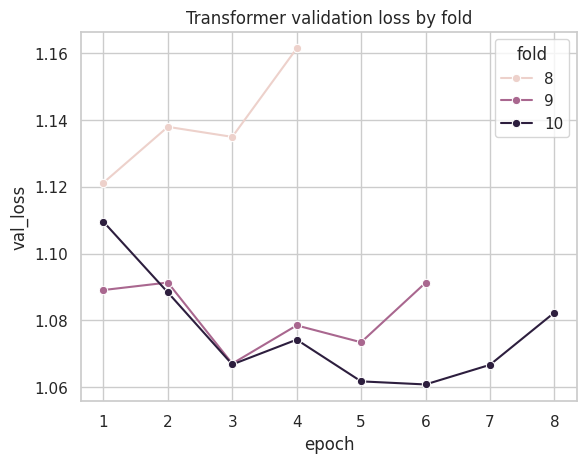

In [10]:
transformer_predictions = []
transformer_histories = []

for fold in tqdm(folds, desc="Transformer walk-forward"):
    tr, te = fold["train_idx"], fold["test_idx"]
    model_t, scaler_t, X_scaled_t, hist_t = train_transformer(X, y, tr)
    probs_t, kept_t = transformer_probs(model_t, X_scaled_t, te)
    transformer_predictions.append(prediction_frame(
        "Transformer", dates[kept_t], y[kept_t], probs_t, fold["fold"]
    ))
    transformer_histories.append(pd.DataFrame(hist_t, columns=["epoch", "train_loss", "val_loss"]).assign(fold=fold["fold"]))
    del model_t
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

transformer_predictions = pd.concat(transformer_predictions, ignore_index=True)
predictions = pd.concat([tabular_predictions, transformer_predictions], ignore_index=True)
display(summarize_predictions(predictions).style.format("{:.4f}"))

history_df = pd.concat(transformer_histories, ignore_index=True)
sns.lineplot(data=history_df, x="epoch", y="val_loss", hue="fold", marker="o")
plt.title("Transformer validation loss by fold")
plt.show()


## 7. 금융 시계열 파운데이션 모델 Kronos-small

Kronos는 OHLCV를 금융시장 전용 토큰으로 변환한 뒤 다음 K-line을 생성합니다. 삼성전자에 별도 학습하지 않은 **zero-shot** 성능을 확인합니다.

- 빠른 모드는 최근 20거래일만 검사합니다.
- 각 날짜마다 여러 경로를 샘플링하고 상승·보합·하락 빈도를 확률로 사용합니다.
- 이 확률은 정식 보정 확률이 아니라 작은 Monte Carlo 표본이므로 해석에 주의하세요.


In [11]:
kronos_predictor = None
kronos_predictions = pd.DataFrame()

if RUN_KRONOS:
    if "/content/Kronos" not in sys.path:
        sys.path.append("/content/Kronos")
    from model import Kronos, KronosTokenizer, KronosPredictor

    kronos_device = "cuda:0" if torch.cuda.is_available() else "cpu"
    tokenizer = KronosTokenizer.from_pretrained("NeoQuasar/Kronos-Tokenizer-base")
    kronos_model = Kronos.from_pretrained("NeoQuasar/Kronos-small")
    kronos_predictor = KronosPredictor(
        kronos_model,
        tokenizer,
        device=kronos_device,
        max_context=512,
    )
    print("Kronos loaded on", kronos_device)
else:
    print("RUN_KRONOS=False: Kronos section skipped")


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/15.8M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.0M [00:00<?, ?B/s]

Kronos loaded on cuda:0


In [12]:
def kronos_probability_for_date(target_date, mc_samples=KRONOS_MC_SAMPLES):
    target_date = pd.Timestamp(target_date).normalize()
    hist = sam.loc[sam.index < target_date].tail(KRONOS_LOOKBACK).copy()
    if len(hist) < 100:
        raise ValueError("Kronos context is too short")

    x_df = hist[["open", "high", "low", "close", "volume"]].copy()
    x_df.columns = ["open", "high", "low", "close", "volume"]
    x_df["volume"] = x_df["volume"].fillna(0).clip(lower=0)
    x_timestamp = pd.Series(hist.index)
    y_timestamp = pd.Series([target_date])
    previous_close = float(hist["close"].iloc[-1])

    sampled_returns = []
    for sample_no in range(mc_samples):
        sample_seed = SEED + sample_no
        random.seed(sample_seed)
        np.random.seed(sample_seed)
        torch.manual_seed(sample_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(sample_seed)

        pred_df = kronos_predictor.predict(
            df=x_df,
            x_timestamp=x_timestamp,
            y_timestamp=y_timestamp,
            pred_len=1,
            T=0.8,
            top_p=0.9,
            sample_count=1,
        )
        predicted_close = float(pred_df["close"].iloc[0])
        sampled_returns.append(predicted_close / previous_close - 1)

    sampled_returns = np.asarray(sampled_returns)
    counts = np.array([
        np.sum(sampled_returns < -NEUTRAL_BAND),
        np.sum((sampled_returns >= -NEUTRAL_BAND) & (sampled_returns <= NEUTRAL_BAND)),
        np.sum(sampled_returns > NEUTRAL_BAND),
    ], dtype=float)
    # 작은 표본에서 확률 0/1을 피하기 위한 Jeffreys smoothing.
    probs = (counts + 0.5) / (counts.sum() + 1.5)
    return probs, sampled_returns


if RUN_KRONOS and kronos_predictor is not None:
    all_test_dates = pd.DatetimeIndex(sorted(predictions["date"].unique()))
    kronos_dates = all_test_dates.intersection(sam.index)[-KRONOS_EVAL_DAYS:]
    rows = []
    for target_date in tqdm(kronos_dates, desc="Kronos zero-shot backtest"):
        try:
            probs_k, sampled_ret = kronos_probability_for_date(target_date)
            true_class = int(model_df.loc[target_date, "target"])
            frame = prediction_frame(
                "Kronos-small",
                [target_date],
                [true_class],
                probs_k.reshape(1, -1),
                fold_id="zero-shot",
                extra={
                    "pred_return_mean": [float(sampled_ret.mean())],
                    "pred_return_std": [float(sampled_ret.std(ddof=0))],
                },
            )
            rows.append(frame)
        except Exception as exc:
            print(f"⚠️ {target_date.date()} Kronos 실패: {exc}")
    if rows:
        kronos_predictions = pd.concat(rows, ignore_index=True)
        predictions = pd.concat([predictions, kronos_predictions], ignore_index=True)
        display(summarize_predictions(kronos_predictions).style.format("{:.4f}"))
    else:
        print("Kronos 예측 결과가 없습니다.")


Kronos zero-shot backtest:   0%|          | 0/20 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00,  2.87it/s]

100%|██████████| 1/1 [00:00<00:00, 87.55it/s]

100%|██████████| 1/1 [00:00<00:00, 89.71it/s]

100%|██████████| 1/1 [00:00<00:00, 91.58it/s]

100%|██████████| 1/1 [00:00<00:00, 91.92it/s]

100%|██████████| 1/1 [00:00<00:00, 93.36it/s]

100%|██████████| 1/1 [00:00<00:00, 86.94it/s]

100%|██████████| 1/1 [00:00<00:00, 84.28it/s]

100%|██████████| 1/1 [00:00<00:00, 77.01it/s]

100%|██████████| 1/1 [00:00<00:00, 88.11it/s]

100%|██████████| 1/1 [00:00<00:00, 90.02it/s]

100%|██████████| 1/1 [00:00<00:00, 90.43it/s]

100%|██████████| 1/1 [00:00<00:00, 90.95it/s]

100%|██████████| 1/1 [00:00<00:00, 90.16it/s]

100%|██████████| 1/1 [00:00<00:00, 93.18it/s]

100%|██████████| 1/1 [00:00<00:00, 87.85it/s]

100%|██████████| 1/1 [00:00<00:00, 89.79it/s]

100%|██████████| 1/1 [00:00<00:00, 86.80it/s]

100%|██████████| 1/1 [00:00<00:00, 87.27it/s]

100%|██████████| 1/1 [00:00<00:00, 87.59it/s]

100%|██████████| 1/1 [00:00<00:00, 90.31it/s]

100%|███████

,n,accuracy,balanced_accuracy,macro_f1,log_loss,brier
model,,,,,,
Kronos-small,20.0000,0.5000,0.3667,0.2749,1.1312,0.6889


## 8. 동일 날짜에서 공정 비교

Kronos는 실행시간 때문에 일부 날짜만 평가하므로, 아래 표는 모든 모델이 동시에 예측한 날짜의 교집합만 사용합니다. `Native window` 표는 각 모델이 가진 전체 예측을 보여주는 참고용입니다.


In [13]:
native_metrics = summarize_predictions(predictions)

model_date_sets = {
    name: set(pd.to_datetime(group["date"]))
    for name, group in predictions.groupby("model")
}
common_dates = set.intersection(*model_date_sets.values())

if len(common_dates) < 10:
    # Kronos가 실패한 경우 나머지 모델의 교집합으로 비교한다.
    non_kronos = predictions[predictions["model"] != "Kronos-small"]
    model_date_sets = {
        name: set(pd.to_datetime(group["date"]))
        for name, group in non_kronos.groupby("model")
    }
    common_dates = set.intersection(*model_date_sets.values())

common_predictions = predictions[predictions["date"].isin(common_dates)].copy()
common_metrics = summarize_predictions(common_predictions)

print("Native-window metrics")
display(native_metrics.style.format("{:.4f}"))
print(f"Common-date metrics (n dates={len(common_dates)})")
display(common_metrics.style.format("{:.4f}"))


Native-window metrics


,n,accuracy,balanced_accuracy,macro_f1,log_loss,brier
model,,,,,,
LightGBM,361.0000,0.5152,0.4673,0.4730,1.0260,0.6104
Logistic,361.0000,0.5208,0.4426,0.4398,1.0154,0.6067
Transformer,361.0000,0.4792,0.3994,0.3558,1.0388,0.6273
Kronos-small,20.0000,0.5000,0.3667,0.2749,1.1312,0.6889
Always flat,361.0000,0.1911,0.3333,0.1070,1.1099,0.6741


Common-date metrics (n dates=20)


,n,accuracy,balanced_accuracy,macro_f1,log_loss,brier
model,,,,,,
Transformer,20.0000,0.6500,0.4630,0.4385,0.9372,0.5619
LightGBM,20.0000,0.6000,0.4185,0.4082,0.9096,0.5565
Logistic,20.0000,0.5500,0.3778,0.3562,1.0544,0.6207
Kronos-small,20.0000,0.5000,0.3667,0.2749,1.1312,0.6889
Always flat,20.0000,0.0500,0.3333,0.0317,1.1100,0.6742


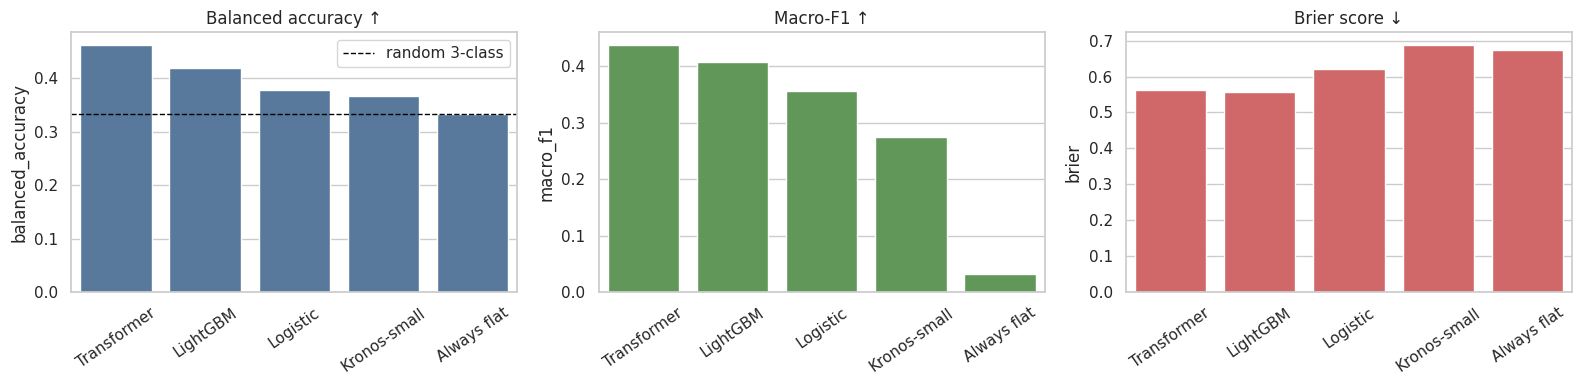

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_metrics = common_metrics.reset_index()
sns.barplot(data=plot_metrics, x="model", y="balanced_accuracy", ax=axes[0], color="#4c78a8")
sns.barplot(data=plot_metrics, x="model", y="macro_f1", ax=axes[1], color="#59a14f")
sns.barplot(data=plot_metrics, x="model", y="brier", ax=axes[2], color="#e15759")
axes[0].axhline(1/3, color="black", ls="--", lw=1, label="random 3-class")
axes[0].legend()
axes[0].set_title("Balanced accuracy ↑")
axes[1].set_title("Macro-F1 ↑")
axes[2].set_title("Brier score ↓")
for ax in axes:
    ax.tick_params(axis="x", rotation=35)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()


/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 46973 (\N{HANGUL SYLLABLE RAG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49849 (\N{HANGUL SYLLABLE SEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/us

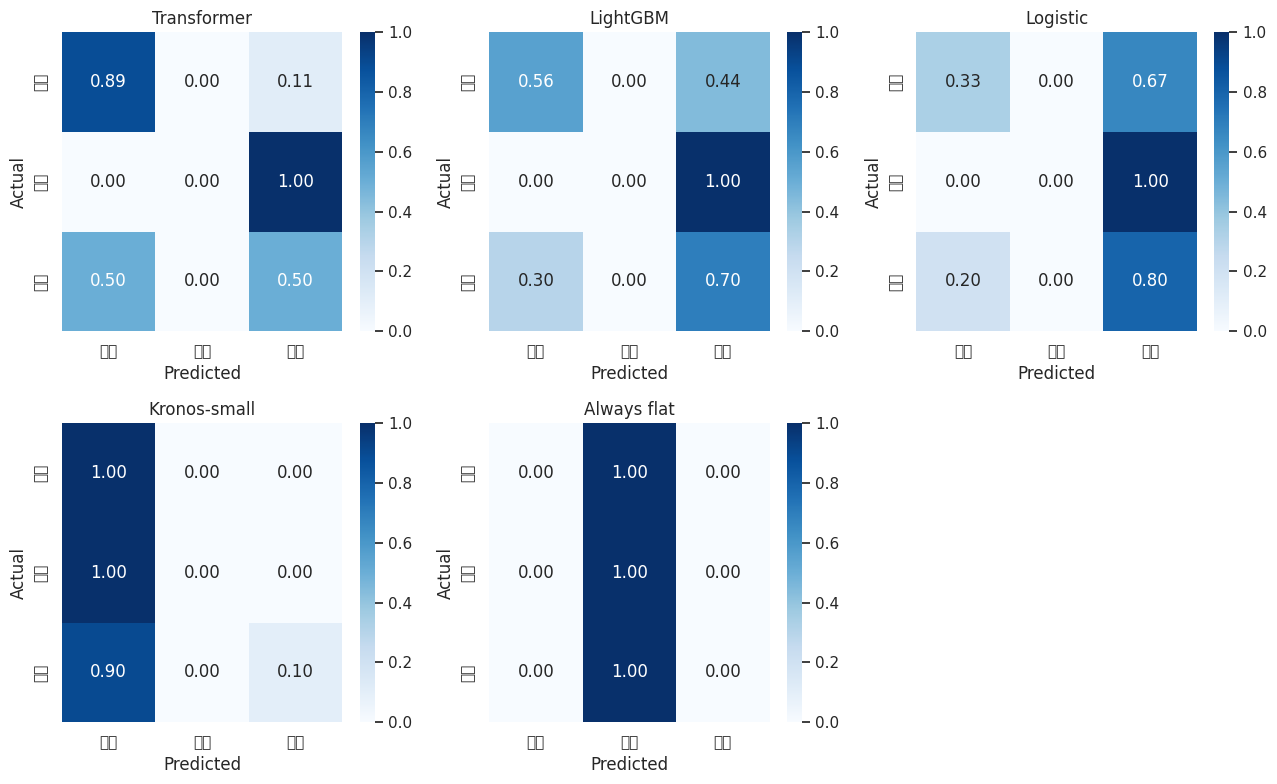

In [15]:
models_to_plot = list(common_metrics.index)
ncols = 3
nrows = math.ceil(len(models_to_plot) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, name in zip(axes, models_to_plot):
    group = common_predictions[common_predictions["model"] == name]
    cm = confusion_matrix(group["y_true"], group["y_pred"], labels=[0, 1, 2], normalize="true")
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=["하락", "보합", "상승"],
        yticklabels=["하락", "보합", "상승"],
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
for ax in axes[len(models_to_plot):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


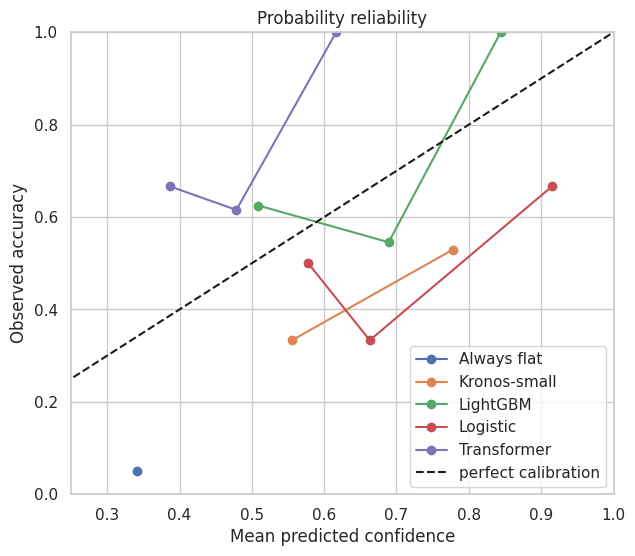

In [16]:
def reliability_table(frame, bins=5):
    work = frame.copy()
    probs = work[PROB_COLS].to_numpy()
    work["confidence"] = probs.max(axis=1)
    work["correct"] = (work["y_true"] == work["y_pred"]).astype(int)
    work["bin"] = pd.cut(work["confidence"], bins=np.linspace(0, 1, bins + 1), include_lowest=True)
    return work.groupby("bin", observed=False).agg(
        n=("correct", "size"),
        mean_confidence=("confidence", "mean"),
        empirical_accuracy=("correct", "mean"),
    ).dropna()


plt.figure(figsize=(7, 6))
for name, group in common_predictions.groupby("model"):
    rel = reliability_table(group)
    if len(rel):
        plt.plot(rel["mean_confidence"], rel["empirical_accuracy"], marker="o", label=name)
plt.plot([0, 1], [0, 1], "k--", label="perfect calibration")
plt.xlim(0.25, 1)
plt.ylim(0, 1)
plt.xlabel("Mean predicted confidence")
plt.ylabel("Observed accuracy")
plt.title("Probability reliability")
plt.legend()
plt.show()


## 9. LightGBM 변수 중요도

중요도는 인과관계가 아니라 분할에 자주 사용된 정도입니다. 여러 폴드의 중요도를 평균합니다.


,mean_split_importance
micron_ret_1,450.333333
sam_volume_z20,411.666667
sam_range_1,402.333333
usdkrw_ret_1,381.666667
vix_ret_1,367.333333
dxy_ret_1,365.666667
sam_ret_1,364.333333
sam_ret_2,357.000000
nvidia_ret_5,340.666667
tsmc_adr_ret_5,330.333333


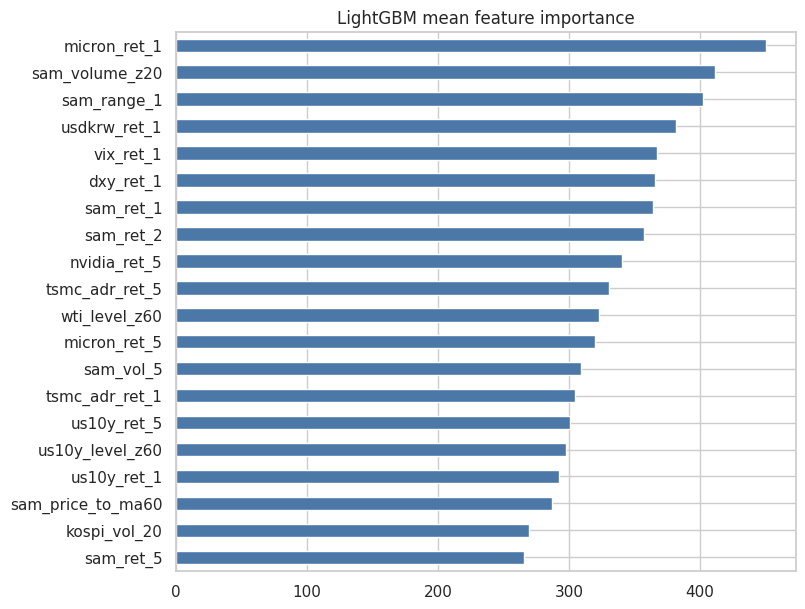

In [17]:
if lgb_importances:
    importance = pd.Series(np.mean(lgb_importances, axis=0), index=feature_cols).sort_values(ascending=False)
    display(importance.head(20).to_frame("mean_split_importance"))
    importance.head(20).sort_values().plot.barh(figsize=(8, 7), color="#4c78a8")
    plt.title("LightGBM mean feature importance")
    plt.show()


## 10. 전체 데이터로 재학습하고 다음 거래일 방향·중기 가격 예측

아래 결과는 노트북 실행 시점의 최신 공개 데이터로 계산됩니다. 기존 다음 거래일 방향과 함께 5거래일(1주일), 20거래일(1개월) 뒤 종가를 직접 회귀 방식으로 예측합니다. 한국 휴일이 끼어 예측 날짜가 틀리면 설정 셀의 `PREDICTION_DATE_OVERRIDE`를 수정하고 특징 생성 이후 셀을 다시 실행하세요.


In [18]:
# Logistic full fit
logistic_full = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=0.25,
        max_iter=3000,
        class_weight="balanced",
        random_state=SEED,
    )),
])
logistic_full.fit(X, y)
live_X = live_row[feature_cols].to_numpy(dtype=np.float32)
p_log_live = logistic_full.predict_proba(live_X)
p_log_live = p_log_live[:, np.argsort(logistic_full.named_steps["model"].classes_)][0]

# LightGBM full fit
lgbm_full = LGBMClassifier(
    objective="multiclass",
    num_class=3,
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=15,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=2.0,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1,
)
lgbm_full.fit(X, y)
p_lgb_live = lgbm_full.predict_proba(live_X)
p_lgb_live = p_lgb_live[:, np.argsort(lgbm_full.classes_)][0]

# Transformer full fit. 마지막 행으로 live feature를 붙여 과거 30일 시퀀스를 만든다.
all_train_idx = np.arange(len(X))
transformer_full, transformer_scaler, _, transformer_full_history = train_transformer(
    X, y, all_train_idx, epochs=TRANSFORMER_EPOCHS
)
X_plus_live = np.vstack([X, live_X])
X_plus_live_scaled = transformer_scaler.transform(X_plus_live).astype(np.float32)
live_seq = torch.from_numpy(X_plus_live_scaled[-SEQ_LEN:][None, ...]).to(DEVICE)
transformer_full.eval()
with torch.no_grad():
    p_transformer_live = torch.softmax(transformer_full(live_seq), dim=1).cpu().numpy()[0]

live_probs = {
    "Logistic": p_log_live,
    "LightGBM": p_lgb_live,
    "Transformer": p_transformer_live,
}

if RUN_KRONOS and kronos_predictor is not None:
    try:
        p_kronos_live, kronos_live_returns = kronos_probability_for_date(prediction_date)
        live_probs["Kronos-small"] = p_kronos_live
    except Exception as exc:
        print("⚠️ Latest Kronos forecast failed:", exc)

# 공통기간 log loss가 낮은 모델에 더 큰 비중을 주는 단순 성과가중 앙상블.
eligible = [name for name in live_probs if name in common_metrics.index]
if eligible:
    losses = np.array([common_metrics.loc[name, "log_loss"] for name in eligible], dtype=float)
    weights = np.exp(-2.0 * (losses - losses.min()))
    weights = weights / weights.sum()
    ensemble = sum(w * live_probs[name] for w, name in zip(weights, eligible))
    ensemble_weights = dict(zip(eligible, weights))
else:
    eligible = list(live_probs)
    ensemble = np.mean([live_probs[name] for name in eligible], axis=0)
    ensemble_weights = {name: 1 / len(eligible) for name in eligible}

live_probs["Performance-weighted ensemble"] = ensemble

live_table = []
for name, probs in live_probs.items():
    probs = np.asarray(probs) / np.asarray(probs).sum()
    pred_class = int(np.argmax(probs))
    live_table.append({
        "model": name,
        "prediction_date": prediction_date.date().isoformat(),
        "prediction": LABEL_NAMES[pred_class],
        "p_down": probs[0],
        "p_flat": probs[1],
        "p_up": probs[2],
    })

live_table = pd.DataFrame(live_table).set_index("model")
print("Ensemble weights:", {k: round(float(v), 3) for k, v in ensemble_weights.items()})
display(live_table.style.format({"p_down": "{:.1%}", "p_flat": "{:.1%}", "p_up": "{:.1%}"}))

/tmp/ipykernel_2882/3465412923.py:16: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
100%|██████████| 1/1 [00:00<00:00, 89.74it/s]

Ensemble weights: {'Logistic': 0.224, 'LightGBM': 0.3, 'Transformer': 0.284, 'Kronos-small': 0.192}


,prediction_date,prediction,p_down,p_flat,p_up
model,,,,,
Logistic,2026-09-03,상승,31.9%,31.6%,36.5%
LightGBM,2026-09-03,상승,20.8%,3.3%,75.9%
Transformer,2026-09-03,상승,36.3%,17.0%,46.8%
Kronos-small,2026-09-03,하락,55.6%,33.3%,11.1%
Performance-weighted ensemble,2026-09-03,상승,34.4%,19.3%,46.3%


### 10.1 1주일·1개월 뒤 예상 종가 최종 보고서

각 시점의 미래 수익률을 Ridge와 LightGBM이 직접 학습합니다. 시계열 검증에서는 예측 구간과 학습 라벨이 겹치지 않도록 horizon만큼 `gap`을 두고, 검증 MAE가 낮은 모델에 더 큰 가중치를 줍니다. `target_date`는 주말만 제외한 예상 거래일이므로 한국 공휴일·임시 휴장일에 따라 실제 거래일과 다를 수 있습니다.


In [19]:
FORECAST_HORIZONS = {"1주일": 5, "1개월": 20}
price_close = sam["close"]


def make_price_regressors():
    return {
        "Ridge": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=10.0)),
        ]),
        "LightGBM": LGBMRegressor(
            objective="regression_l1",
            n_estimators=300,
            learning_rate=0.03,
            num_leaves=15,
            min_child_samples=30,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.5,
            reg_lambda=2.0,
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1,
        ),
    }


def fit_price_ensemble(horizon, live_features):
    # 행 d의 특징은 d-1 종가까지만 포함한다. 목표값은 d-1 종가 대비
    # horizon번째 거래일(d+horizon-1)의 실제 종가 수익률이다.
    future_return = price_close.shift(-(horizon - 1)) / price_close.shift(1) - 1
    regression_df = feat.loc[sam.index, feature_cols].copy()
    regression_df["future_return"] = future_return.reindex(regression_df.index)
    regression_df = regression_df.replace([np.inf, -np.inf], np.nan).dropna()

    X_reg = regression_df[feature_cols].to_numpy(dtype=np.float32)
    y_reg = regression_df["future_return"].to_numpy(dtype=np.float32)
    n_splits = 3 if QUICK_MODE else 5
    splitter = TimeSeriesSplit(n_splits=n_splits, gap=horizon - 1)
    templates = make_price_regressors()

    validation_mae = {}
    for name, template in templates.items():
        absolute_errors = []
        for train_idx, valid_idx in splitter.split(X_reg):
            fold_model = clone(template)
            fold_model.fit(X_reg[train_idx], y_reg[train_idx])
            fold_prediction = fold_model.predict(X_reg[valid_idx])
            absolute_errors.extend(np.abs(y_reg[valid_idx] - fold_prediction))
        validation_mae[name] = float(np.mean(absolute_errors))

    inverse_mae = {name: 1.0 / max(mae, 1e-8) for name, mae in validation_mae.items()}
    inverse_sum = sum(inverse_mae.values())
    weights = {name: value / inverse_sum for name, value in inverse_mae.items()}

    fitted_models = {}
    model_predictions = {}
    for name, template in templates.items():
        fitted_model = clone(template)
        fitted_model.fit(X_reg, y_reg)
        fitted_models[name] = fitted_model
        model_predictions[name] = float(fitted_model.predict(live_features)[0])

    ensemble_return = sum(weights[name] * model_predictions[name] for name in weights)
    lower_bound, upper_bound = np.quantile(y_reg, [0.01, 0.99])
    ensemble_return = float(np.clip(ensemble_return, lower_bound, upper_bound))
    return ensemble_return, validation_mae, weights, fitted_models


current_close = float(price_close.iloc[-1])
price_forecast_rows = []
price_forecast_validation_mae = {}
price_forecast_weights = {}
price_forecast_models = {}

for horizon_label, horizon in FORECAST_HORIZONS.items():
    predicted_return, validation_mae, model_weights, fitted_models = fit_price_ensemble(
        horizon, live_X
    )
    target_date = pd.bdate_range(prediction_date, periods=horizon)[-1]
    price_forecast_validation_mae[horizon_label] = {
        name: float(value) for name, value in validation_mae.items()
    }
    price_forecast_weights[horizon_label] = {
        name: float(value) for name, value in model_weights.items()
    }
    price_forecast_models[horizon_label] = fitted_models
    price_forecast_rows.append({
        "horizon": horizon_label,
        "trading_days": horizon,
        "as_of_date": last_samsung_date.date().isoformat(),
        "target_date": target_date.date().isoformat(),
        "current_close": current_close,
        "predicted_return": predicted_return,
        "predicted_close": current_close * (1 + predicted_return),
        "validation_mae": sum(
            model_weights[name] * validation_mae[name] for name in model_weights
        ),
        "model_weights": json.dumps(
            {name: round(float(value), 4) for name, value in model_weights.items()},
            ensure_ascii=False,
        ),
    })

price_forecast_table = pd.DataFrame(price_forecast_rows).set_index("horizon")
print("중기 가격 예측 최종 보고서")
print("※ 예상 날짜는 주말만 제외하며 한국 공휴일·임시 휴장일은 반영하지 않습니다.")
display(price_forecast_table.style.format({
    "current_close": "{:,.0f}원",
    "predicted_return": "{:+.2%}",
    "predicted_close": "{:,.0f}원",
    "validation_mae": "{:.2%}",
}))


중기 가격 예측 최종 보고서
※ 예상 날짜는 주말만 제외하며 한국 공휴일·임시 휴장일은 반영하지 않습니다.


,trading_days,as_of_date,target_date,current_close,predicted_return,predicted_close,validation_mae,model_weights
horizon,,,,,,,,
1주일,5,2026-09-02,2026-09-09,"250,500원",+1.50%,"254,267원",3.38%,"{""Ridge"": 0.4941, ""LightGBM"": 0.5059}"
1개월,20,2026-09-02,2026-09-30,"250,500원",+5.17%,"263,455원",7.76%,"{""Ridge"": 0.5025, ""LightGBM"": 0.4975}"


## 11. 결과 저장

백테스트 예측, 공통기간 성능, 다음 거래일 방향, 1주일·1개월 가격 예측, 학습 모델과 설정을 `/content/samsung_direction_outputs.zip`으로 묶습니다. 마지막 줄의 다운로드 코드는 주석을 해제해 사용하세요.


In [20]:
OUTPUT_DIR = Path("/content/samsung_direction_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

predictions.sort_values(["date", "model"]).to_csv(OUTPUT_DIR / "backtest_predictions.csv", index=False)
native_metrics.to_csv(OUTPUT_DIR / "metrics_native_window.csv")
common_metrics.to_csv(OUTPUT_DIR / "metrics_common_dates.csv")
live_table.to_csv(OUTPUT_DIR / "latest_forecast.csv")
price_forecast_table.to_csv(OUTPUT_DIR / "multi_horizon_price_forecast.csv")
pd.Series(feature_cols, name="feature").to_csv(OUTPUT_DIR / "feature_list.csv", index=False)

config = {
    "start_date": START_DATE,
    "neutral_band": NEUTRAL_BAND,
    "first_test_date": FIRST_TEST_DATE,
    "test_months": TEST_MONTHS,
    "rolling_train_years": ROLLING_TRAIN_YEARS,
    "quick_mode": QUICK_MODE,
    "seq_len": SEQ_LEN,
    "transformer_epochs": TRANSFORMER_EPOCHS,
    "run_kronos": RUN_KRONOS,
    "kronos_eval_days": KRONOS_EVAL_DAYS,
    "kronos_mc_samples": KRONOS_MC_SAMPLES,
    "prediction_date": prediction_date.date().isoformat(),
    "forecast_horizons": FORECAST_HORIZONS,
    "ensemble_weights": {k: float(v) for k, v in ensemble_weights.items()},
    "price_forecast_validation_mae": price_forecast_validation_mae,
    "price_forecast_weights": price_forecast_weights,
}
(OUTPUT_DIR / "config.json").write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")

joblib.dump(logistic_full, OUTPUT_DIR / "logistic_model.joblib")
joblib.dump(lgbm_full, OUTPUT_DIR / "lightgbm_model.joblib")
joblib.dump(transformer_scaler, OUTPUT_DIR / "transformer_scaler.joblib")
for horizon_label, fitted_models in price_forecast_models.items():
    for model_name, fitted_model in fitted_models.items():
        horizon_days = FORECAST_HORIZONS[horizon_label]
        safe_model_name = model_name.lower().replace(" ", "_")
        joblib.dump(
            fitted_model,
            OUTPUT_DIR / f"price_{horizon_days}d_{safe_model_name}.joblib",
        )
torch.save({
    "state_dict": {k: v.detach().cpu() for k, v in transformer_full.state_dict().items()},
    "n_features": len(feature_cols),
    "seq_len": SEQ_LEN,
    "feature_cols": feature_cols,
}, OUTPUT_DIR / "transformer_model.pt")

archive_path = "/content/samsung_direction_outputs"
import shutil
zip_path = shutil.make_archive(archive_path, "zip", OUTPUT_DIR)
print("Saved:", zip_path)

# 필요할 때 아래 두 줄의 주석을 해제하세요.
# from google.colab import files
# files.download(zip_path)


Saved: /content/samsung_direction_outputs.zip


## 12. 결과 해석 체크리스트

1. **항상 보합**보다 `balanced_accuracy`, `macro_f1`이 높은가?
2. 한두 날짜가 아니라 여러 워크포워드 구간에서 반복되는가?
3. `log_loss`, `brier`도 좋아 확률이 과신되지 않았는가?
4. 하락·보합·상승 중 한 클래스만 잘 맞히는 것은 아닌가?
5. Kronos 결과는 동일 날짜 표본이 충분한가? 빠른 모드 20일만으로 결론 내리지 마세요.
6. 전체 모드에서도 우위가 없으면 최신 모델이라는 이유만으로 채택하지 마세요.

### 다음 개선 순서

- KRX 투자자별 수급·선물·옵션 데이터를 발표시각 기준으로 추가
- 오전 8시 50분 예상체결가와 주문불균형을 별도 장직전 모델에 추가
- 데이터 기간과 보합 밴드에 대한 민감도 분석
- Kronos가 유망할 때만 한국 주식 데이터로 파인튜닝
- 최소 월 1회 재학습, 매일 예측 결과와 실제 종가 기록

### 참고 자료

- [Kronos 논문](https://arxiv.org/abs/2508.02739) · [공식 구현](https://github.com/shiyu-coder/Kronos)
- [Re(Visiting) Time Series Foundation Models in Finance](https://arxiv.org/abs/2511.18578)
- [FinVerse 금융 시계열 벤치마크](https://arxiv.org/abs/2608.03259)
- [KRX Data Marketplace](https://data.krx.co.kr/)

> 이 노트북은 연구 및 교육 목적이며 투자 조언이 아닙니다.
